In [1]:
using LorenzParameterEstimation
using Plots, Random, Statistics, LinearAlgebra
using StatsBase, PlotlyJS, Revise, Profile, ProfileView, ProfileCanvas, Optimisers
rng = MersenneTwister(1234)

MersenneTwister(1234)

In [2]:
# ---------- helpers ----------
"""
Estimate symmetric support halfwidth (range of grid) from solution samples.
method = :percentile (p in (0,1)) or :max.
"""
function estimate_halfwidth(sol; burn_frac=0.1, stride=2, method=:percentile, p=0.995, margin=1.2)
    start_idx = max(2, floor(Int, 1 + burn_frac*size(sol.u,1)))
    idx = start_idx:stride:size(sol.u,1)
    @assert !isempty(idx) "idx is empty"
    X = reduce(hcat, (view(sol.u, i, :) for i in idx))
    mask = [all(isfinite, col) for col in eachcol(X)]
    X = X[:, mask]
    @assert !isempty(X) "all samples non-finite"
    if method === :percentile
        lo = quantile(vec(abs.(X)), 1 - p)  # not used directly; keep symmetric
        hw = quantile(vec(abs.(X)), p) * margin
    else
        hw = maximum(abs, X) * margin
    end
    return float(hw)
end

"""
Build normalized soft 3D target PDF with label smoothing.
"""
function make_target_pdf(x, y, z, centers; h_mult=0.6, α=1e-3, R=nothing)
    Δ = (centers[end]-centers[1])/(length(centers)-1)
    h = h_mult * Δ
    R === nothing && (R = max(1, ceil(Int, 4h/Δ)))
    p3d = zeros(Float64, length(centers)^3)
    soft_hist_3d_local(x, y, z, centers, h, p3d; R=R)
    s = sum(p3d); @assert s > 0 "hist sum zero"
    p3d ./= s
    p3d .= (1-α) .* p3d .+ α/length(p3d)
    return (centers=centers, p3d=p3d), h
end

make_target_pdf

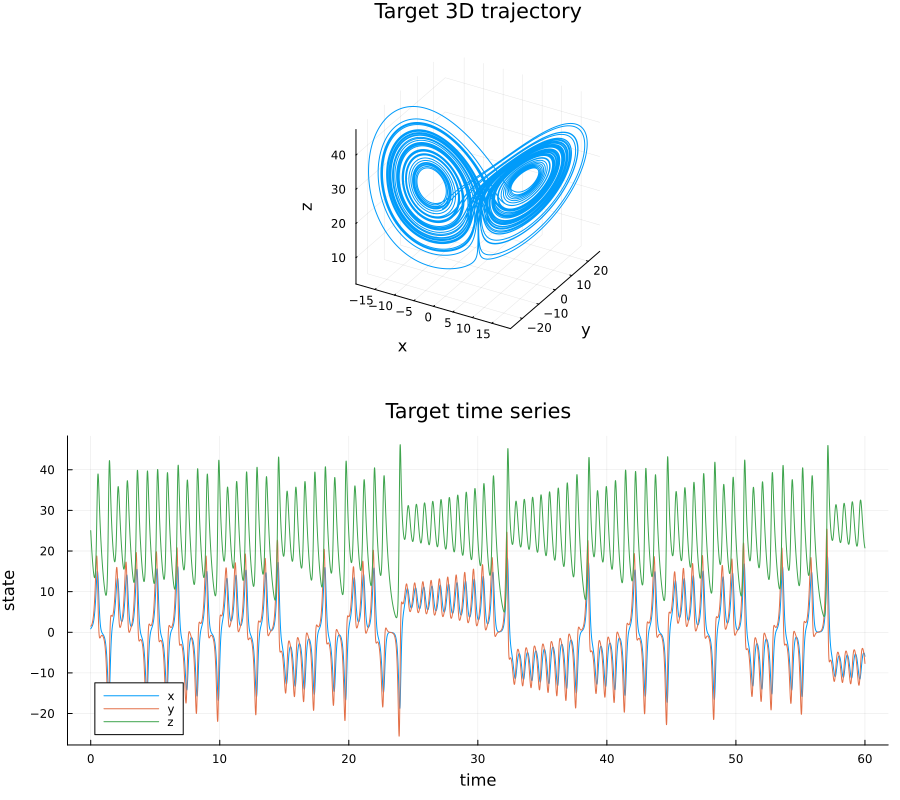

In [3]:
target_params = classic_params()
T_total = 60.0
steps_long = 50000
dt_long = T_total / steps_long


ics_test = [[1.0, 1.0, 25.0] .+ 0.20 .* randn(rng, 3) for _ in 1:256]
U0  = hcat(ics_test...)
sol_tgt = integrate(target_params, @view(U0[:,1]), (0.0, T_total), dt_long)

# plot the target solution: 3D trajectory + time series
x = sol_tgt.u[:, 1]
y = sol_tgt.u[:, 2]
z = sol_tgt.u[:, 3]
t = sol_tgt.t

p1 = Plots.plot(x, y, z;
    seriestype = :path3d, lw = 1,
    title = "Target 3D trajectory", xlabel = "x", ylabel = "y", zlabel = "z",
    legend = false)

p2 = Plots.plot(t, hcat(x, y, z);
    label = ["x" "y" "z"], xlabel = "time", ylabel = "state",
    title = "Target time series")

Plots.plot(p1, p2, layout = (2,1), size = (900, 800))

In [4]:
# ---------- choose consistent knobs ----------
nbins      = 96
burn_frac  = 0.0
stride     = 2
loss_mode  = :cross_entropy  # use :kl if you prefer
h_mult     = 0.06            # bandwidth = h_mult * Δ
margin     = 1.0             # for halfwidth estimation
# ---------- dynamics + ICs ----------
target_params = classic_params()
T_total = 60.0
steps_long = 10000
dt_long = T_total / steps_long

0.006

UnifiedTrain | PDF3D loss=cross_entropy | dt=0.006 steps=10000 | ICs=64 | k=4000 | bins=96^3
Init  | σ=10.000000 ρ=27.550000 β=2.666667 x_s=0.000000 y_s=0.000000 z_s=0.000000 θ=1.000000
  Gradients clipped (norm 5.196e+22 > 100.00)
Epoch    1 | σ=10.000000 (Δ0.00e+00)  ρ=27.553000 (Δ3.00e-03)  β=2.666667 (Δ0.00e+00)  | loss=1.006801e+01 | g_norm=1.000e+02
  Gradients clipped (norm 2.649e+23 > 100.00)
Epoch   10 | σ=10.000000 (Δ0.00e+00)  ρ=27.566133 (Δ1.16e-03)  β=2.666667 (Δ0.00e+00)  | loss=1.011573e+01 | g_norm=1.000e+02
  Gradients clipped (norm 9.717e+22 > 100.00)
Epoch   20 | σ=10.000000 (Δ0.00e+00)  ρ=27.570692 (Δ4.05e-04)  β=2.666667 (Δ0.00e+00)  | loss=9.869084e+00 | g_norm=1.000e+02
  Gradients clipped (norm 9.450e+22 > 100.00)
Epoch   30 | σ=10.000000 (Δ0.00e+00)  ρ=27.576294 (Δ4.66e-04)  β=2.666667 (Δ0.00e+00)  | loss=9.988254e+00 | g_norm=1.000e+02
  Gradients clipped (norm 3.418e+23 > 100.00)
Epoch   40 | σ=10.000000 (Δ0.00e+00)  ρ=27.573709 (Δ5.95e-05)  β=2.666667 (Δ0.00

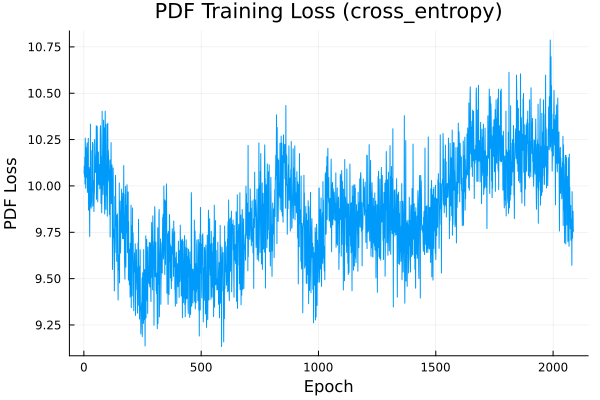

In [6]:
# widen IC spread
ics_test = [[1.0, 1.0, 25.0] .+ 2.5 .* randn(rng, 3) for _ in 1:64]
U0  = hcat(ics_test...)
sol_tgt = integrate(target_params, @view(U0[:,1]), (0.0, T_total), dt_long)

# plot the target solution: 3D trajectory + time series
x = sol_tgt.u[:, 1]
y = sol_tgt.u[:, 2]
z = sol_tgt.u[:, 3]
t = sol_tgt.t

p1 = Plots.plot(x, y, z;
    seriestype = :path3d, lw = 1,
    title = "Target 3D trajectory", xlabel = "x", ylabel = "y", zlabel = "z",
    legend = false)

p2 = Plots.plot(t, hcat(x, y, z);
    label = ["x" "y" "z"], xlabel = "time", ylabel = "state",
    title = "Target time series")

Plots.plot(p1, p2, layout = (2,1), size = (900, 800))

# ---------- compute halfwidth (don’t guess) ----------
halfwidth = estimate_halfwidth(sol_tgt; burn_frac=burn_frac, stride=stride,
                               method=:percentile, p=0.995, margin=margin)
        

# ---------- centers via make_pdf_config (single source of truth) ----------
# compute grid spacing Δ from range halfwidth and number of bins
Δ = 2 * halfwidth / (nbins - 1)
# bandwidth
h = h_mult * Δ

pdf_cfg = make_pdf_config(Float64;
    nbins=nbins,
    range_halfwidth=halfwidth,
    bandwidth=h,     # let make_pdf_config set h = 0.5Δ; we’ll override below
    loss_mode=loss_mode,
)

@assert length(pdf_cfg.centers) > 1 "need at least 2 centers to compute Δ"
Δ = float(Δ)

# ---------- target PDF (uses the same centers/bandwidth logic) ----------
target_pdf, _h = make_target_pdf(x, y, z, pdf_cfg.centers; h_mult=h_mult, α=1e-3)

# ---------- neutral schedule ----------
sched = PdfSchedule{Float64}(h_mult, h_mult, 1)

# ---------- climate config ----------
cfg = ClimateConfig(
    dt = dt_long,
    steps = steps_long,
    samples_per_epoch = 4000,  # ↑ gradient SNR
    initial_conditions = U0,
    pdf = pdf_cfg,
    schedule = sched,
    rng = rng,
    batch_size = 8,            # 0 → full-batch over ICs (deterministic)
)

# ---------- train: update only ρ ----------
init_params = L63Parameters(σ=10.0, ρ=27.55, β=8/3)

res = train_statistics(
    init_params;
    target = target_pdf,
    stats = (:pdf3d,),
    optimizer = Optimisers.Adam(3e-3),
    update_mask = (σ=false, ρ=true, β=false, x_s=false, y_s=false, z_s=false, θ=false),
    epochs = 10_000,
    refresh = 10,
    early_stopping_patience = 1_500,
    early_stopping_min_delta = 1e-6,
    rel_delta = 1e-5,
    cfg = cfg,
    verbose = true,
    gradient_verbose = false,
    gradient_clip_norm = 1e2,
)

println("Init: $(init_params)\nRecovered: $(res.params)\nTarget: $(target_params)")

Plots.plot(res.loss_history; xlabel="Epoch", ylabel="PDF Loss",
     title="PDF Training Loss ($(String(loss_mode)))", legend=false)

In [7]:
# Loss landscape vs ρ (no deps)
###############################
# Requires in scope:
#   L63Parameters, classic_params, integrate,
#   soft_hist_3d_local, hard_hist_3d

# --- lightweight losses (vector-on-vector) ---
@inline function _ce_vec(p::AbstractVector{T}, q::AbstractVector{T}) where {T}
    ϵ = T(1e-12); s = zero(T)
    @inbounds for i in eachindex(p,q)
        s += -p[i]*log(q[i] + ϵ)
    end
    s
end

@inline function _kl_vec(p::AbstractVector{T}, q::AbstractVector{T}) where {T}
    ϵ = T(1e-12); s = zero(T)
    @inbounds for i in eachindex(p,q)
        pi = max(p[i], ϵ); qi = max(q[i], ϵ)
        s += pi*(log(pi) - log(qi))
    end
    s
end


# --- helper: build a 3D pdf with burn-in + subsampling, pooled across all ICs ---
function _build_pdf_for(params::L63Parameters, U0::AbstractMatrix,
                        T_total::Real, steps::Int;
                        burn_frac::Real=0.6, stride::Int=3,
                        centers::AbstractVector, h::Real, R::Int,
                        hard_hist::Bool=false)
    dt = T_total / steps
    tspan = (0.0, T_total)
    m = length(centers)
    p3d = zeros(eltype(centers), m^3)

    # accumulate samples from all ICs
    for b in 1:size(U0,2)
        sol = integrate(params, @view(U0[:,b]), tspan, dt)
        U = sol.u
        n = size(U,1)
        start = max(2, floor(Int, 1 + burn_frac*n))
        idx = start:stride:n
        xs = U[idx,1]; ys = U[idx,2]; zs = U[idx,3]

        # accumulate once per IC (normalize at the end globally)
        tmp = zeros(eltype(centers), m^3)
        if hard_hist
            # hard histogram needs no h/R
            hard_hist_3d(xs, ys, zs, centers, tmp)
        else
            soft_hist_3d_local(xs, ys, zs, centers, h, tmp; R=R)
        end
        @. p3d += tmp
    end

    s = sum(p3d)
    s > 0 ? (@. p3d = p3d / s) : fill!(p3d, 1/length(p3d))
    return p3d
end

# pick centers (& Δ) from a target trajectory span and a margin
function _make_centers_from_traj(U::AbstractMatrix, nbins::Int; margin::Real=1.5)
    hw = maximum(abs, vcat(U[:,1], U[:,2], U[:,3])) * margin
    centers = collect(range(-hw, hw; length=nbins))
    Δ = (centers[end] - centers[1])/(nbins-1)
    return centers, Δ
end

"""
loss_curve_rho(; kwargs...) -> (rho_vals, losses[, plt])

Compute L(ρ) against a target PDF (from `classic_params()`) using the SAME
hyperparameters you choose for the sweep.
"""
function loss_curve_rho(; rho_grid = 22.0:0.5:32.0,
    fixed_sigma::Real = 10.0, fixed_beta::Real = 8/3,
    T_total::Real = 60.0, steps::Int = 2400,
    burn_frac::Real = 0.6, stride::Int = 3,
    nbins::Int = 24, h_mult::Real = 1.5, margin::Real = 1.5,
    U0 = [1.0, 1.0, 25.0],         # 3-vector or 3×B matrix
    loss_mode::Symbol = :cross_entropy,
    make_plot::Bool = true,
    hard_hist::Bool = false)

    # ensure U0 is a 3×B matrix
    U0mat = (ndims(U0) == 1) ? reshape(Float64.(U0), 3, 1) : Float64.(U0)

    # 1) TARGET pdf using classic_params() under the SAME hyperparams
    dt = T_total / steps
    sol_tgt = integrate(classic_params(), @view(U0mat[:,1]), (0.0, T_total), dt)
    centers, Δ = _make_centers_from_traj(sol_tgt.u, nbins; margin=margin)
    h = h_mult * Δ
    R = max(1, ceil(Int, 3h/Δ))

    target_pdf = _build_pdf_for(classic_params(), U0mat, T_total, steps;
                                burn_frac=burn_frac, stride=stride,
                                centers=centers, h=h, R=R, hard_hist=hard_hist)

    # 2) Evaluate loss for each ρ on same grid/bandwidth
    vals = collect(rho_grid)
    losses = Vector{Float64}(undef, length(vals))

    loss_fun = loss_mode === :cross_entropy ? _ce_vec :
               loss_mode === :kl            ? _kl_vec :
               error("loss_mode must be :cross_entropy or :kl")

    for (i, ρ) in enumerate(vals)
        p = L63Parameters(fixed_sigma, ρ, fixed_beta, 0, 0, 0, 1)
        p3d = _build_pdf_for(p, U0mat, T_total, steps;
                             burn_frac=burn_frac, stride=stride,
                             centers=centers, h=h, R=R, hard_hist=hard_hist)
        losses[i] = loss_fun(target_pdf, p3d)
    end

    if make_plot
        # caller must have `using Plots` in scope
        plt = Plots.plot(vals, losses; xlabel="ρ", ylabel="Loss",
                         title="Loss vs ρ ($(String(loss_mode)))",
                         legend=false, linewidth=2)
        return vals, losses, plt
    else
        return vals, losses
    end
end

loss_curve_rho

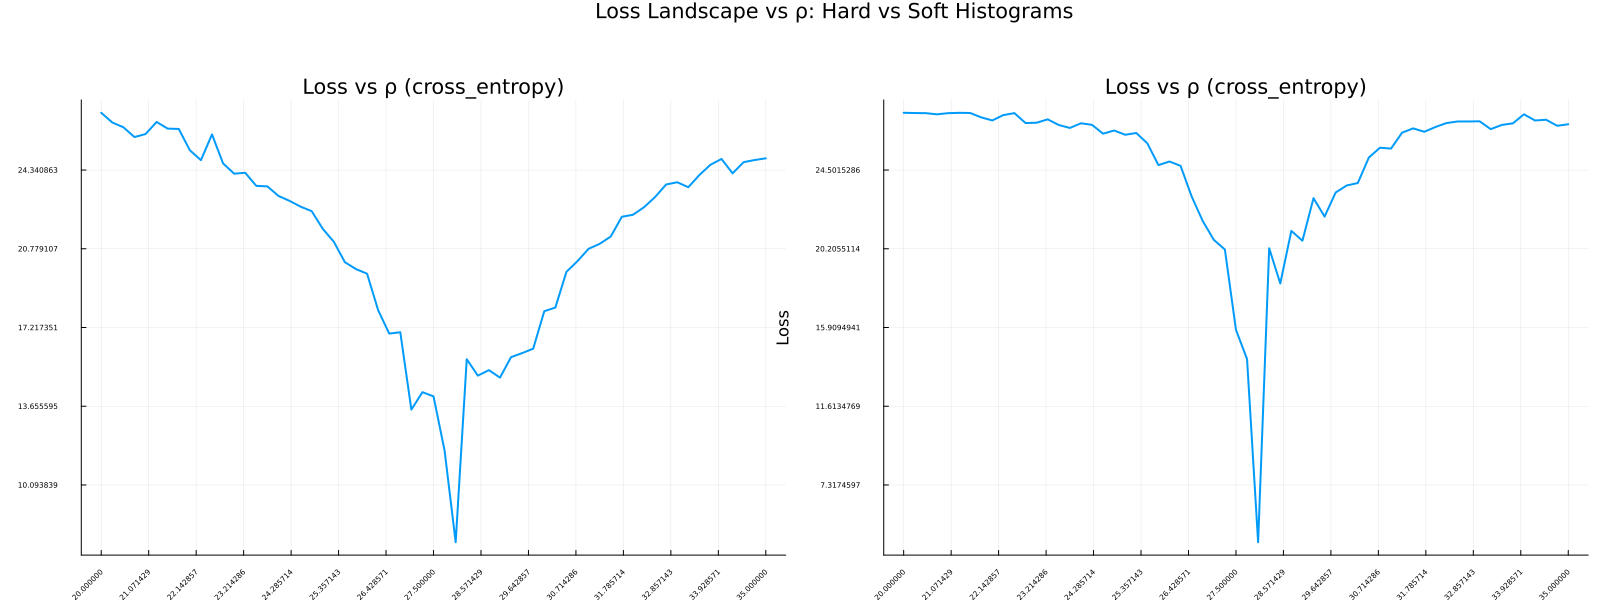

In [8]:
# Change parameters here once to affect both sweeps
common = (
    rho_grid = 20.0:0.25:35.0,
    fixed_sigma = 10.0,
    fixed_beta = 8/3,
    T_total = round(T_total),
    steps = round(Int,steps_long),
    burn_frac = 0,
    stride = 2,
    nbins = nbins,
    h_mult = h_mult,
    margin = margin*0.9,
    loss_mode = loss_mode,
    make_plot = true,
)

ρ_vals1, losses1, plt1 = loss_curve_rho(; common..., hard_hist = true)
ρ_vals2, losses2, plt2 = loss_curve_rho(; common..., hard_hist = false)

# increase ticks: use more x-ticks across rho range and a few y-ticks with slight padding
xt = collect(range(first(ρ_vals1), last(ρ_vals1); length=15))

pad1 = (maximum(losses1) - minimum(losses1)) * 0.05
pad1 = pad1 == 0 ? 1e-6 : pad1
yt1 = collect(range(minimum(losses1) - pad1, maximum(losses1) + pad1; length=7))

pad2 = (maximum(losses2) - minimum(losses2)) * 0.05
pad2 = pad2 == 0 ? 1e-6 : pad2
yt2 = collect(range(minimum(losses2) - pad2, maximum(losses2) + pad2; length=7))

# rotate xticks and increase plot size
xrot = 45
tf = Plots.font(5)

Plots.plot!(plt1, xticks=xt, yticks=yt1, xrotation=xrot, tickfont=tf)
Plots.plot!(plt2, xticks=xt, yticks=yt2, xrotation=xrot, tickfont=tf)

# display the two loss curves side-by-side (bigger)
l = @layout [a{0.08h}; [b c]]
plt_title = Plots.plot(legend=false, grid=false, framestyle=:none,
                 title="Loss Landscape vs ρ: Hard vs Soft Histograms",
                 xticks=false, yticks=false)
size_large = (1600, 600)
plt_compare = Plots.plot(plt_title, plt1, plt2; layout=l, size=size_large)
display(plt_compare)


In [30]:
@noinline function _loss_entry_pdf3d(σ, ρ, β, x_s, y_s, z_s, θ,
                                     dt::S, steps::Int,
                                     U::AbstractMatrix{S}, I::AbstractVector{Int},
                                     centers::AbstractVector{S}, h::S,
                                     p3d_t::AbstractVector{S},
                                     mode::Symbol, sinkε::S, sinkiters::Int)::S where {S<:Real}
    _loss_pdf_core_3d(σ, ρ, β, x_s, y_s, z_s, θ,
                      dt, steps, U, I, centers, h, p3d_t, mode, sinkε, sinkiters)
end

_loss_entry_pdf3d (generic function with 1 method)

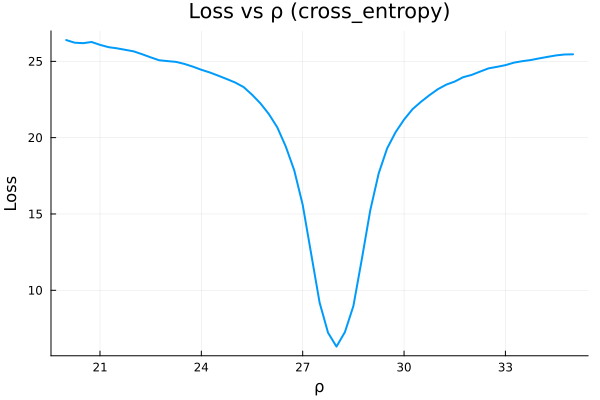

In [20]:
# prepare ICs (64 ICs) and call loss_curve_rho with the requested kwargs
ics_test = [[1.0, 1.0, 25.0] .+ 2.5 .* randn(rng, 3) for _ in 1:64]
U0 = hcat(ics_test...)

ρ_vals, losses, plt = loss_curve_rho(
    rho_grid = 20.0:0.25:35.0,
    fixed_sigma = 10.0,
    fixed_beta = 8/3,
    T_total = round(T_total),
    steps = round(Int, steps_long),
    burn_frac = 0,
    stride = 2,
    nbins = nbins,
    h_mult = h_mult,
    margin = margin*0.9,
    loss_mode = loss_mode,
    make_plot = true,
    U0 = U0,
    combine_mode = :pool,   # or :avg
    hard_hist = false
)

display(plt)

In [12]:
# Plot loss vs ρ (x-axis = ρ, y-axis = loss) from `res`.
function plot_rho_vs_loss(res)
    @assert hasproperty(res, :loss_history) "res has no field `loss_history`"
    loss = Float64.(res.loss_history)

    cand_names = (:params_history, :param_history, :params_traj, :param_traj,
                  :parameter_history, :params_hist, :history, :trace)
    ph = nothing
    for n in cand_names
        if hasproperty(res, n)
            ph = getproperty(res, n)
            break
        end
    end
    if ph === nothing && hasproperty(res, :history)
        h = getproperty(res, :history)
        for n in cand_names
            if hasproperty(h, n)
                ph = getproperty(h, n)
                break
            end
        end
        if ph === nothing && hasproperty(h, :params)
            ph = getproperty(h, :params)
        end
    end

    function try_get(p, syms...)
        for s in syms
            try
                return getproperty(p, s)
            catch
            end
            try
                return p[s]
            catch
            end
        end
        return nothing
    end

    if ph === nothing
        @warn "No parameter history found in `res`."
        return
    end

    ph_list = collect(ph)
    len = min(length(loss), length(ph_list))

    rho_names = (:ρ, :rho, :r)
    rho_vec = Float64[]
    for i in 1:len
        p = ph_list[i]
        rv = try_get(p, rho_names...)
        push!(rho_vec, rv === nothing ? NaN : Float64(rv))
    end

    idx = findall(isfinite, rho_vec)
    if isempty(idx)
        @warn "No finite ρ values found."
        return
    end

    rf = rho_vec[idx]
    lf = loss[idx]

    plt = Plots.plot(rf, lf; xlabel="ρ", ylabel="Loss", title="Loss vs ρ", legend=false, seriestype=:path, linewidth=2)
    Plots.scatter!(rf, lf; ms=4)
    display(plt)
end


plot_rho_vs_loss (generic function with 1 method)

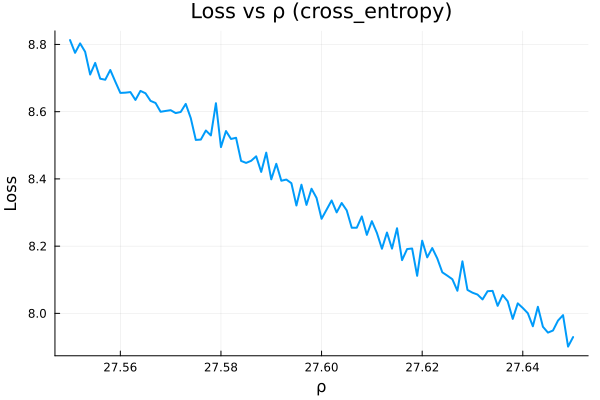

In [28]:
# prepare ICs (64 ICs) and call loss_curve_rho with the requested kwargs
ics_test = [[1.0, 1.0, 25.0] .+ 2.5 .* randn(rng, 3) for _ in 1:64]
U0 = hcat(ics_test...)

ρ_vals, losses, plt = loss_curve_rho(
    rho_grid = 27.55:0.001:27.65,
    fixed_sigma = 10.0,
    fixed_beta = 8/3,
    T_total = round(T_total),
    steps = round(Int, steps_long),
    burn_frac = 0,
    stride = 2,
    nbins = nbins,
    h_mult = h_mult,
    margin = margin*0.9,
    loss_mode = loss_mode,
    make_plot = true,
    U0 = U0,
    combine_mode = :pool,   # or :avg
    hard_hist = false
)

display(plt)

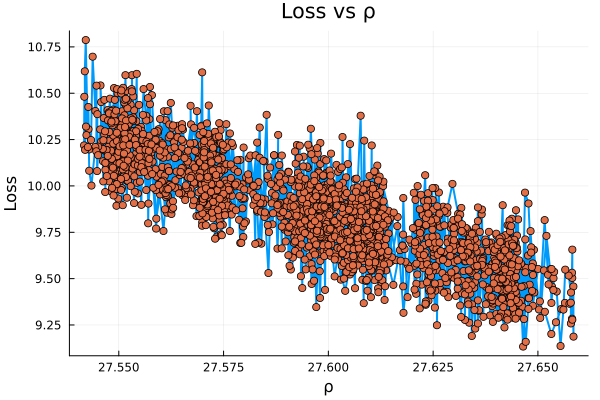

In [13]:
plot_rho_vs_loss(res)